/tmp/ipykernel_17844/3323907313.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


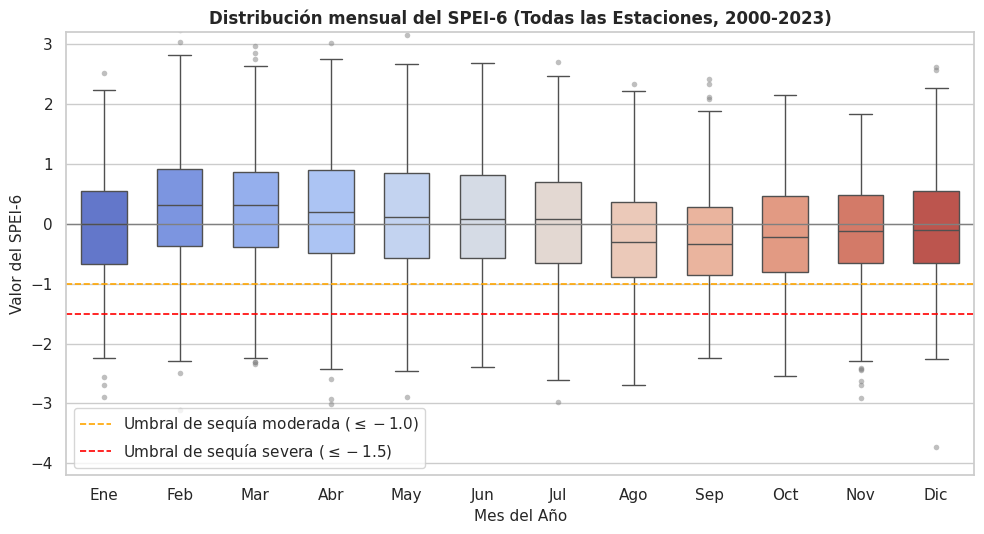

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga y preparación de datos
df_datos = pd.read_csv('../../data/processed/datos_mensuales_con_spei.csv')
df_datos['fecha'] = pd.to_datetime(df_datos['fecha'])
df_datos['mes'] = df_datos['fecha'].dt.month

# Nombres de los meses en español para el eje X
meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# 2. Configuración del gráfico
plt.figure(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")

# Crear el boxplot con paleta de color "coolwarm" para reflejar térmicamente el ciclo anual
sns.boxplot(
    data=df_datos, x='mes', y='spei_6', 
    palette="coolwarm", width=0.6, showfliers=True,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5, markeredgecolor='none')
)

# Agregar líneas de referencia climatológica y sequía
plt.axhline(0, color='gray', linestyle='-', linewidth=1)
plt.axhline(-1.0, color='orange', linestyle='--', linewidth=1.2, label=r'Umbral de sequía moderada ($\leq -1.0$)')
plt.axhline(-1.5, color='red', linestyle='--', linewidth=1.2, label=r'Umbral de sequía severa ($\leq -1.5$)')

# Ajustes de etiquetas y títulos
plt.title("Distribución mensual del SPEI-6 (Todas las Estaciones, 2000-2023)", fontweight='bold', fontsize=12)
plt.xlabel("Mes del Año", fontsize=11)
plt.ylabel("Valor del SPEI-6", fontsize=11)
plt.xticks(ticks=range(12), labels=meses_es)
plt.ylim(-4.2, 3.2)
plt.legend(loc='lower left', frameon=True)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('distribucion_mensual_spei6.png', dpi=300)
plt.show()